# EDA — proprete.csv
Score de Vivabilité · Signalements de propreté urbaine à Paris (DansMaRue)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

## 1. Chargement

In [4]:
from pathlib import Path

BASE_DIR = Path(__file__).resolve().parents[1] if '__file__' in dir() else Path.cwd().parents[0]
FILE = BASE_DIR / 'brute' / 'score_de_vivabilité' / 'proprete.csv'

df = pd.read_csv(FILE, sep=None, engine='python')
df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=False)
df['DATE DECLARATION'] = pd.to_datetime(df['DATE DECLARATION'], errors='coerce')
print(f'Shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head()

Shape : (1184561, 17)
Colonnes : ['ID DECLARATION', 'TYPE DECLARATION', 'SOUS TYPE DECLARATION', 'ADRESSE', 'CODE POSTAL', 'VILLE', 'ARRONDISSEMENT', 'CONSEIL DE QUARTIER', 'DATE DECLARATION', 'ANNEE DECLARATION', 'MOIS DECLARATION', 'OUTIL SOURCE', 'INTERVENANT', 'ID_DMR', 'geo_shape', 'geo_point_2d', 'mois_annee_decla']


,ID DECLARATION,TYPE DECLARATION,SOUS TYPE DECLARATION,ADRESSE,CODE POSTAL,VILLE,ARRONDISSEMENT,CONSEIL DE QUARTIER,DATE DECLARATION,ANNEE DECLARATION,MOIS DECLARATION,OUTIL SOURCE,INTERVENANT,ID_DMR,geo_shape,geo_point_2d,mois_annee_decla
0,80764,"Autos, motos, vélos, trottinettes...",[] Automobile ou autre véhicule motorisé en st...,"28 Rue Jean Rey, 75015 PARIS",75015.0,Paris 15,15,DUPLEIX - LA MOTTE PICQUET,2025-03-15,2025,3,IOS application,DPMP-Divisions,A2025C080764,"{""coordinates"": [2.2932195997139626, 48.855899...","48.85589999882184, 2.2932195997139626",2025-03
1,34275,Propreté,[] Patrouille propreté Fonctionnelle,"50 Boulevard de Belleville, 75020 PARIS",75020.0,Paris 20,20,BELLEVILLE,2025-08-08,2025,8,Android,DPE-STPP-Fonctionnelle,G2025H034275,"{""coordinates"": [2.38090999985394, 48.86890999...","48.86890999901846, 2.38090999985394",2025-08
2,118900,Objets abandonnés,Autres objets encombrants abandonnés,"18 Rue de Torcy, 75018 PARIS",75018.0,Paris 18,18,LA CHAPELLE - MARX DORMOY,2025-04-22,2025,4,Android,DPE-STPP-DT,G2025D118900,"{""coordinates"": [2.363483000059108, 48.8913149...","48.89131499906259, 2.363483000059108",2025-04
3,80349,Objets abandonnés,Autres objets encombrants abandonnés,"56 Avenue Jean Moulin, 75014 PARIS",75014.0,Paris 14,14,JEAN MOULIN - PORTE D'ORLEANS,2025-04-14,2025,4,Android,DPE-STPP-DT,G2025D080349,"{""coordinates"": [2.321845999738899, 48.8257599...","48.825759999204614, 2.321845999738899",2025-04
4,123685,Objets abandonnés,Autres objets encombrants abandonnés,"68 Rue de Meaux, 75019 PARIS",75019.0,Paris 19,19,SECRETAN,2025-03-23,2025,3,Android,DPE-STPP-DT,G2025C123685,"{""coordinates"": [2.3765496995056283, 48.883155...","48.883155999159335, 2.3765496995056283",2025-03


## 2. Infos générales

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1184561 entries, 0 to 1184560
Data columns (total 17 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   ID DECLARATION         1184561 non-null  int64         
 1   TYPE DECLARATION       1184561 non-null  str           
 2   SOUS TYPE DECLARATION  1184557 non-null  str           
 3   ADRESSE                1184561 non-null  str           
 4   CODE POSTAL            1184559 non-null  float64       
 5   VILLE                  1184561 non-null  str           
 6   ARRONDISSEMENT         1184561 non-null  int64         
 7   CONSEIL DE QUARTIER    1184473 non-null  str           
 8   DATE DECLARATION       1184561 non-null  datetime64[us]
 9   ANNEE DECLARATION      1184561 non-null  int64         
 10  MOIS DECLARATION       1184561 non-null  int64         
 11  OUTIL SOURCE           1184561 non-null  str           
 12  INTERVENANT            1184559 non-null

In [6]:
df.describe(include='all')

,ID DECLARATION,TYPE DECLARATION,SOUS TYPE DECLARATION,ADRESSE,CODE POSTAL,VILLE,ARRONDISSEMENT,CONSEIL DE QUARTIER,DATE DECLARATION,ANNEE DECLARATION,MOIS DECLARATION,OUTIL SOURCE,INTERVENANT,ID_DMR,geo_shape,geo_point_2d,mois_annee_decla
count,1.184561e+06,1184561,1184557,1184561,1.184559e+06,1184561,1.184561e+06,1184473,1184561,1.184561e+06,1.184561e+06,1184561,1184559,1184561,1184561,1184561,1184561
unique,NaN,11,349,192256,NaN,23,NaN,117,NaN,NaN,NaN,4,49,1184561,756570,756570,14
top,NaN,Objets abandonnés,Autres objets encombrants abandonnés,"Bois de Vincennes Route de la Pyramide, 75012 ...",NaN,Paris 18,NaN,BELLEVILLE,NaN,NaN,NaN,Android,DPE-STPP-DT,A2025C080764,"{""coordinates"": [2.360248999507263, 48.8555869...","48.85558699931011, 2.360248999507263",2025-03
freq,NaN,516648,408284,465,NaN,106330,NaN,28000,NaN,NaN,NaN,721696,720415,1,249,249,97378
mean,8.034508e+04,NaN,NaN,NaN,7.501623e+04,NaN,1.312969e+01,NaN,2025-07-20 08:07:03.869433,2.025105e+03,5.882235e+00,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000e+00,NaN,NaN,NaN,7.500000e+04,NaN,0.000000e+00,NaN,2025-01-01 00:00:00,2.025000e+03,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN
25%,3.905700e+04,NaN,NaN,NaN,7.501000e+04,NaN,1.000000e+01,NaN,2025-04-09 00:00:00,2.025000e+03,3.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN
50%,7.839000e+04,NaN,NaN,NaN,7.501400e+04,NaN,1.400000e+01,NaN,2025-07-15 00:00:00,2.025000e+03,6.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.213470e+05,NaN,NaN,NaN,7.501800e+04,NaN,1.800000e+01,NaN,2025-10-28 00:00:00,2.025000e+03,9.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN
max,1.750190e+05,NaN,NaN,NaN,9.430000e+04,NaN,8.200000e+01,NaN,2026-02-12 00:00:00,2.026000e+03,1.200000e+01,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Valeurs manquantes — critique pour ce dataset

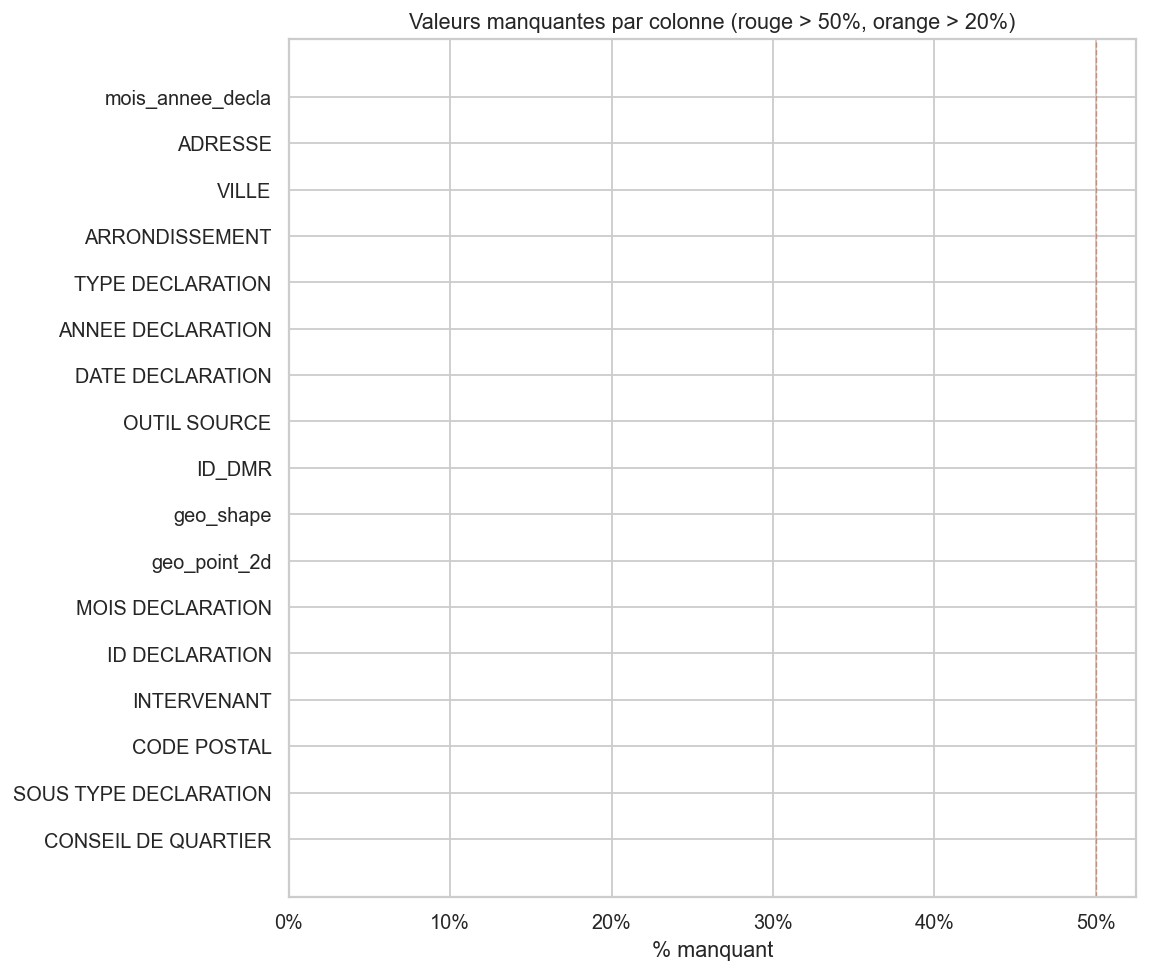

,% manquant
CONSEIL DE QUARTIER,0.007429
SOUS TYPE DECLARATION,0.000338
CODE POSTAL,0.000169
INTERVENANT,0.000169
ID DECLARATION,0.000000
MOIS DECLARATION,0.000000
geo_point_2d,0.000000
geo_shape,0.000000
ID_DMR,0.000000
OUTIL SOURCE,0.000000


In [7]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, max(3, len(df.columns) * 0.45)))
colors = ['#D85A30' if v > 50 else '#BA7517' if v > 20 else '#1D9E75' for v in missing.values]
ax.barh(missing.index, missing.values, color=colors)
ax.set_xlabel('% manquant')
ax.set_title('Valeurs manquantes par colonne (rouge > 50%, orange > 20%)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.axvline(50, color='#D85A30', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

display(missing.rename('% manquant').to_frame())

## 4. Doublons

In [8]:
n_dup = df.duplicated().sum()
print(f'Doublons : {n_dup} ({n_dup/len(df)*100:.2f}%)')
if n_dup > 0:
    display(df[df.duplicated(keep=False)].head(10))

Doublons : 0 (0.00%)


## 5. Détection colonnes clés

In [9]:
def find_col(df, *keywords):
    for kw in keywords:
        match = [c for c in df.columns if kw.lower() in c.lower()]
        if match: return match[0]
    return None

col_map = {
    'id'           : find_col(df, 'id declaration', 'id_dmr', 'identifiant'),
    'type'         : find_col(df, 'type declaration', 'type decl'),
    'sous_type'    : find_col(df, 'sous type', 'sous_type'),
    'date'         : find_col(df, 'date declaration', 'date_decl'),
    'arrondissement': find_col(df, 'arrondissement', 'arrond'),
    'geo_point'    : find_col(df, 'geo_point', 'geopoint', 'coord'),
    'mois'         : find_col(df, 'mois declaration', 'mois_decl'),
    'annee'        : find_col(df, 'annee declaration', 'annee_decl'),
}

print('Colonnes détectées :')
for k, v in col_map.items():
    status = '✅' if v else '❌'
    print(f'  {status}  {k:20s} → {v}')
print(f'\nColonnes non mappées : {[c for c in df.columns if c not in col_map.values()]}')

Colonnes détectées :
  ✅  id                   → ID DECLARATION
  ✅  type                 → TYPE DECLARATION
  ✅  sous_type            → SOUS TYPE DECLARATION
  ✅  date                 → DATE DECLARATION
  ✅  arrondissement       → ARRONDISSEMENT
  ✅  geo_point            → geo_point_2d
  ✅  mois                 → MOIS DECLARATION
  ✅  annee                → ANNEE DECLARATION

Colonnes non mappées : ['ADRESSE', 'CODE POSTAL', 'VILLE', 'CONSEIL DE QUARTIER', 'OUTIL SOURCE', 'INTERVENANT', 'ID_DMR', 'geo_shape', 'mois_annee_decla']


## 6. Répartition par type de déclaration

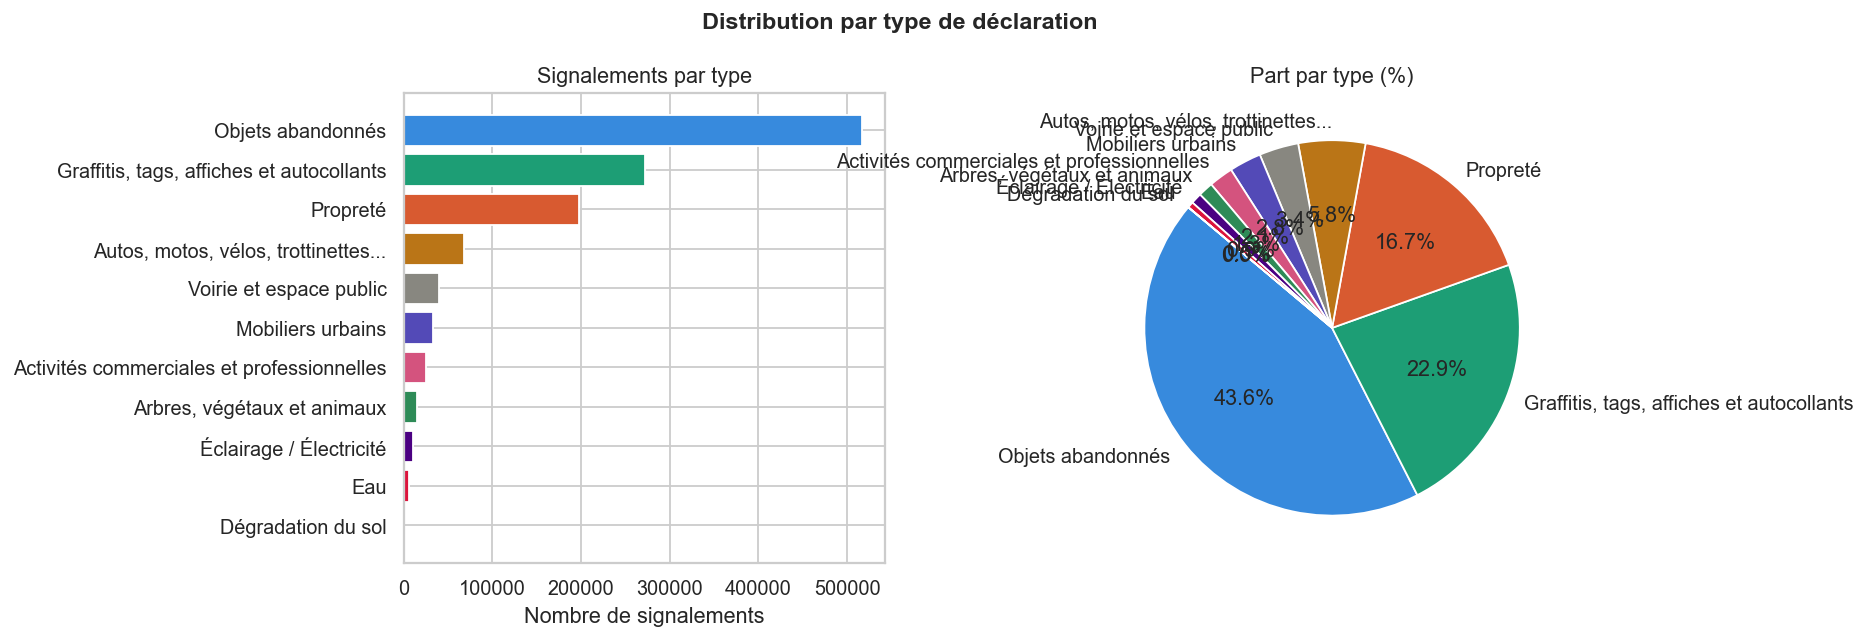

,count
TYPE DECLARATION,
Objets abandonnés,516648
"Graffitis, tags, affiches et autocollants",271852
Propreté,197641
"Autos, motos, vélos, trottinettes...",68273
Voirie et espace public,40179
Mobiliers urbains,32693
Activités commerciales et professionnelles,24775
"Arbres, végétaux et animaux",15182
Éclairage / Électricité,11076


In [10]:
type_col = col_map['type']
if type_col:
    vc_type = df[type_col].value_counts()
    colors = ['#378ADD','#1D9E75','#D85A30','#BA7517','#888780','#534AB7','#D4537E','#2E8B57','#4B0082','#DC143C']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.barh(vc_type.index, vc_type.values, color=colors[:len(vc_type)])
    ax1.set_title('Signalements par type')
    ax1.set_xlabel('Nombre de signalements')
    ax1.invert_yaxis()

    ax2.pie(vc_type.values, labels=vc_type.index, autopct='%1.1f%%',
            colors=colors[:len(vc_type)], startangle=140)
    ax2.set_title('Part par type (%)')

    plt.suptitle('Distribution par type de déclaration', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    display(vc_type.rename('count').to_frame())

## 7. Répartition par arrondissement

Complétude arrondissement : 1184561/1184561 (100.0%)


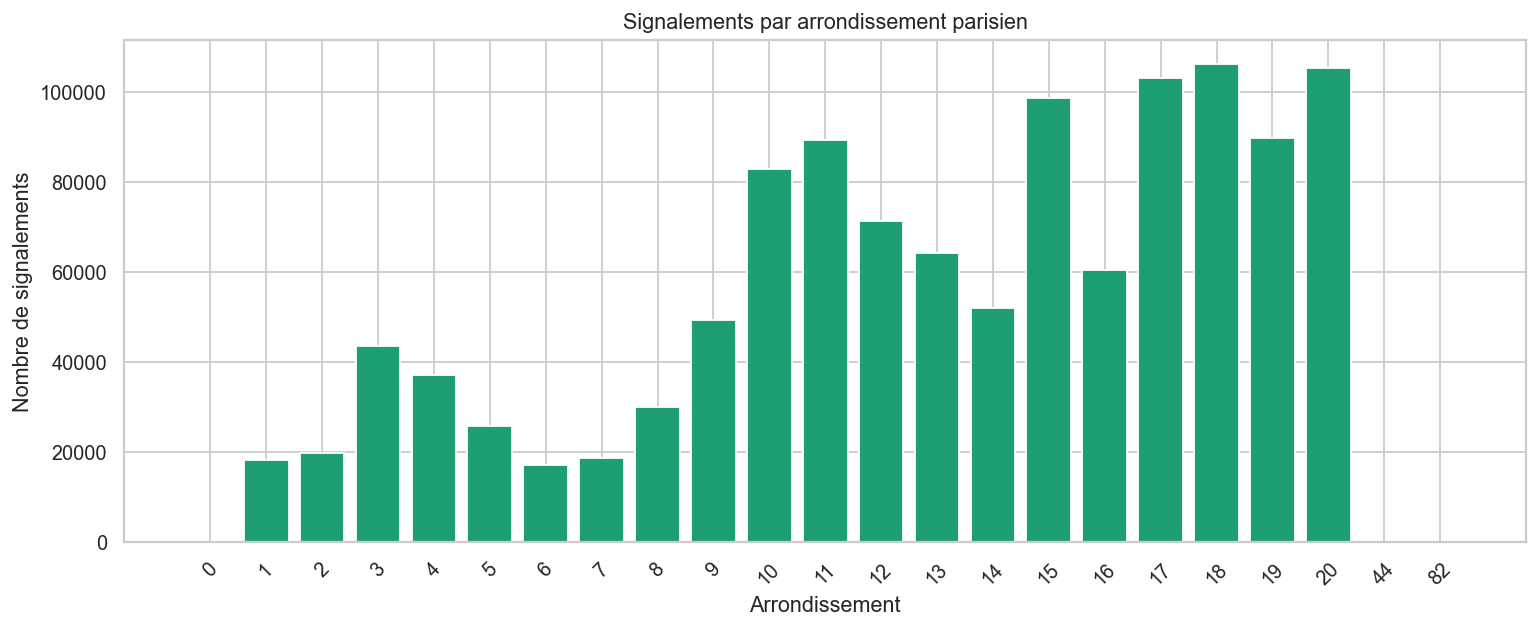

In [11]:
arr_col = col_map['arrondissement']
if arr_col:
    print(f'Complétude arrondissement : {df[arr_col].notna().sum()}/{len(df)} ({df[arr_col].notna().mean()*100:.1f}%)')
    vc_arr = df[arr_col].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(vc_arr.index.astype(str), vc_arr.values, color='#1D9E75')
    ax.set_title('Signalements par arrondissement parisien')
    ax.set_xlabel('Arrondissement')
    ax.set_ylabel('Nombre de signalements')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('❌ Colonne arrondissement non trouvée')

## 8. Évolution temporelle des signalements

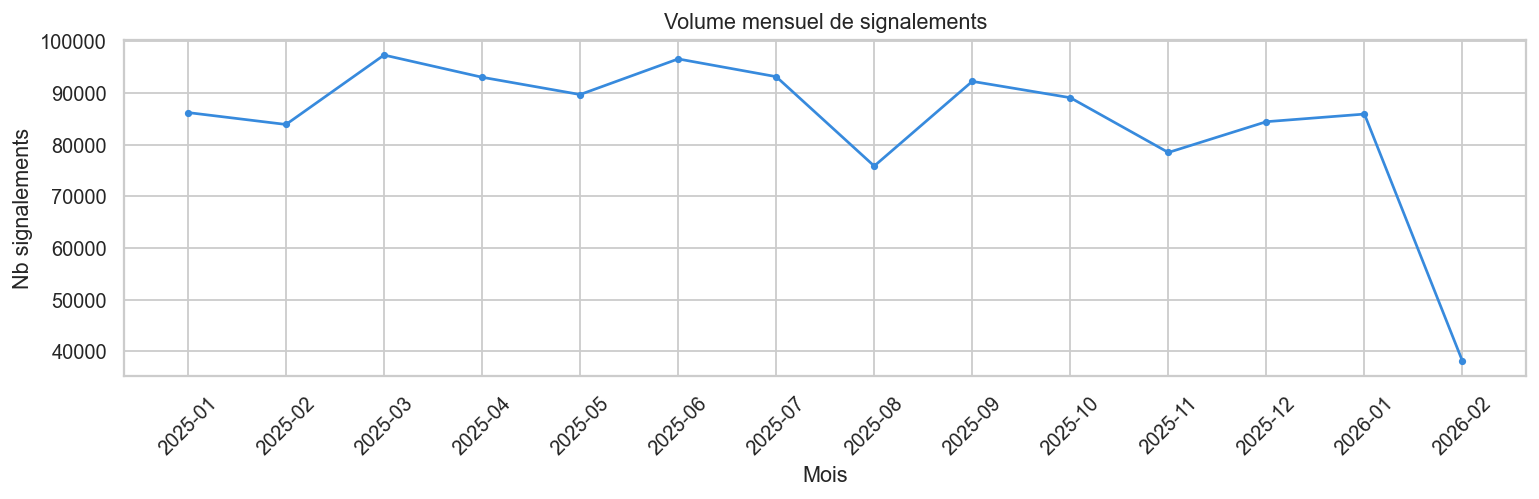

In [12]:
date_col = col_map['date']
if date_col and pd.api.types.is_datetime64_any_dtype(df[date_col]):
    df['mois_period'] = df[date_col].dt.to_period('M')
    ts = df.groupby('mois_period').size()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(ts.index.astype(str), ts.values, color='#378ADD', marker='o', markersize=3)
    ax.set_title('Volume mensuel de signalements')
    ax.set_xlabel('Mois')
    ax.set_ylabel('Nb signalements')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 9. Cardinalité des colonnes catégorielles

In [13]:
cat_cols = df.select_dtypes(include='object').columns
cardinality = pd.DataFrame({
    'colonne'    : cat_cols,
    'unique'     : [df[c].nunique() for c in cat_cols],
    'exemple'    : [str(df[c].dropna().iloc[0])[:50] if not df[c].dropna().empty else 'N/A' for c in cat_cols],
    '% manquant' : [round(df[c].isnull().mean() * 100, 1) for c in cat_cols],
}).sort_values('unique', ascending=False)

display(cardinality)

/var/folders/qb/k892z_d577q8nhdfb8x4fnrh0000gn/T/ipykernel_12490/4111300450.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


,colonne,unique,exemple,% manquant
7,ID_DMR,1184561,A2025C080764,0.0
8,geo_shape,756570,"{""coordinates"": [2.2932195997139626, 48.855899...",0.0
9,geo_point_2d,756570,"48.85589999882184, 2.2932195997139626",0.0
2,ADRESSE,192256,"28 Rue Jean Rey, 75015 PARIS",0.0
1,SOUS TYPE DECLARATION,349,[] Automobile ou autre véhicule motorisé en st...,0.0
4,CONSEIL DE QUARTIER,117,DUPLEIX - LA MOTTE PICQUET,0.0
6,INTERVENANT,49,DPMP-Divisions,0.0
3,VILLE,23,Paris 15,0.0
10,mois_annee_decla,14,2025-03,0.0
0,TYPE DECLARATION,11,"Autos, motos, vélos, trottinettes...",0.0


## 10. Résumé + plan Silver

In [14]:
print('=' * 55)
print('RÉSUMÉ EDA — proprete.csv')
print('=' * 55)
print(f'  Lignes              : {len(df):,}')
print(f'  Colonnes            : {len(df.columns)}')
print(f'  Doublons            : {df.duplicated().sum()}')
missing_count = (df.isnull().sum() > 0).sum()
print(f'  Cols avec NaN       : {missing_count}')
if col_map['arrondissement']: print(f'  Arrondissements     : {df[col_map["arrondissement"]].nunique()}')
if col_map['type']:           print(f'  Types déclaration   : {df[col_map["type"]].nunique()}')
if col_map['sous_type']:      print(f'  Sous-types          : {df[col_map["sous_type"]].nunique()}')
if col_map['date']:           print(f'  Période             : {df[col_map["date"]].min().date()} → {df[col_map["date"]].max().date()}')
print('=' * 55)
print()
print('ACTIONS SILVER REQUISES :')
print('  → Parser geo_point_2d ("lat, lon") en deux colonnes float')
print('  → Corriger CODE POSTAL aberrant 75248 → 75020')
print('  → Agréger par arrondissement + mois pour volumétrie')
print('  → Score propreté = nb signalements / population arrondissement')
print('  → Pondérer par gravité (encombrants > graffitis > autre)')
print('  → Export Parquet pour Gold scoring vivabilité')

RÉSUMÉ EDA — proprete.csv
  Lignes              : 1,184,561
  Colonnes            : 18
  Doublons            : 0
  Cols avec NaN       : 4
  Arrondissements     : 23
  Types déclaration   : 11
  Sous-types          : 349
  Période             : 2025-01-01 → 2026-02-12

ACTIONS SILVER REQUISES :
  → Parser geo_point_2d ("lat, lon") en deux colonnes float
  → Corriger CODE POSTAL aberrant 75248 → 75020
  → Agréger par arrondissement + mois pour volumétrie
  → Score propreté = nb signalements / population arrondissement
  → Pondérer par gravité (encombrants > graffitis > autre)
  → Export Parquet pour Gold scoring vivabilité
